In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager

font_dir = Path("/Users/sophiazhang/anaconda3/envs/shuoz/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf")
font_paths = [
    font_dir / "Myriad Pro Regular.ttf",
    font_dir / "Myriad Pro Bold.ttf",
    font_dir / "MYRIADPRO-SEMIBOLD.OTF"
]

for path in font_paths:
    font_manager.fontManager.addfont(str(path))

plt.rcParams["font.family"] = "Myriad Pro"

fs=16
fss=14

RESULTS_DIR = Path("./results/robustness_DP_ICT")

In [29]:
fp = Path("./results/robustness_substitution/robustness_substitution_yearly.csv")
out_dir = Path("./results/robustness_substitution")
out_dir.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(fp)
df = df.sort_values(["theta", "year"])
df["year"] = df["year"].astype(int)

def interpolate_by_theta(df, theta_col="theta", year_col="year"):
    out = []
    for theta, g in df.groupby(theta_col):
        g = g.copy().sort_values(year_col)
        g[year_col] = g[year_col].astype(int)
        g = g.set_index(year_col)
        full_years = np.arange(g.index.min(), g.index.max() + 1)
        g = g.reindex(full_years)
        g[theta_col] = theta
        num_cols = g.select_dtypes(include=[np.number]).columns
        g[num_cols] = g[num_cols].interpolate(method="linear", limit_direction="both")
        g = g.reset_index().rename(columns={"index": year_col})
        out.append(g)
    return pd.concat(out, ignore_index=True)

df_plot = interpolate_by_theta(df)
theta_values = sorted(df_plot["theta"].unique())

colors = {
    0.0: "#2C7FB8",
    0.2: "#7FCDBB",
    0.5: "#FEE08B",
    0.8: "#F46D43"
}

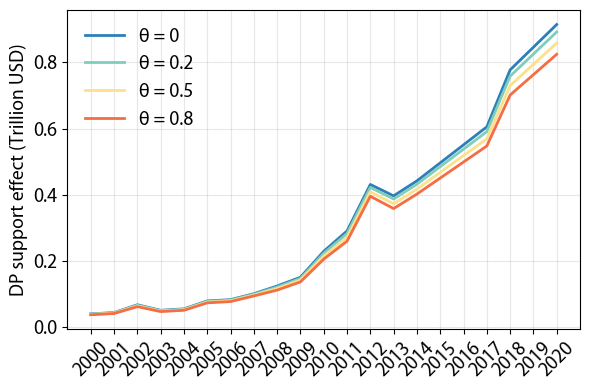

In [30]:
# =========================
# Figure 1:
# DP support effect under different substitution assumptions
# =========================
fig, ax = plt.subplots(figsize=(6, 4), facecolor="none")
for theta in theta_values:
    g = df_plot[df_plot["theta"] == theta]
    years = g["year"].astype(int)
    ax.plot(
        years,
        g["DP_Support_theta"]/1e6,
        linewidth=2,
        label=f"θ = {theta:g}",
        color=colors[theta]
    )
ax.set_ylabel("DP support effect (Trillion USD)", fontsize=fss)
# ax.set_title("Sensitivity of DP supply-chain support effect to substitution assumptions")
ax.set_xticks(years)
ax.set_xticklabels(years.astype(int), fontsize=fss, rotation=45)
ax.tick_params(labelsize=fss)
ax.legend(fontsize=fss, frameon=False)
ax.grid(alpha=0.3)
ax.set_facecolor('none')
fig.tight_layout()
fig.savefig(out_dir / "DP_support_effect_by_theta.png", dpi=300)
plt.show()

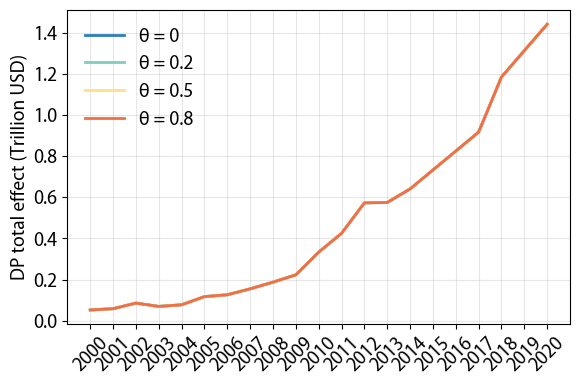

In [31]:
# =========================
# Figure 2:
# DP total effect under different substitution assumptions
# =========================
fig, ax = plt.subplots(figsize=(6, 4), facecolor="none")
for theta in theta_values:
    g = df_plot[df_plot["theta"] == theta]
    years = g["year"].astype(int)
    ax.plot(
        years,
        g["DP_TotalEffect_theta"]/1e6,
        linewidth=2,
        label=f"θ = {theta:g}",
        color=colors[theta]
    )
ax.set_ylabel("DP total effect (Trillion USD)", fontsize=fss)
# ax.set_title("Sensitivity of DP total effect to substitution assumptions")
ax.set_xticks(years)
ax.set_xticklabels(years.astype(int), fontsize=fss, rotation=45)
ax.tick_params(labelsize=fss)
ax.legend(fontsize=fss, frameon=False)
ax.grid(alpha=0.3)
ax.set_facecolor('none')
fig.tight_layout()
fig.savefig(out_dir / "DP_total_effect_by_theta.png", dpi=300)
plt.show()

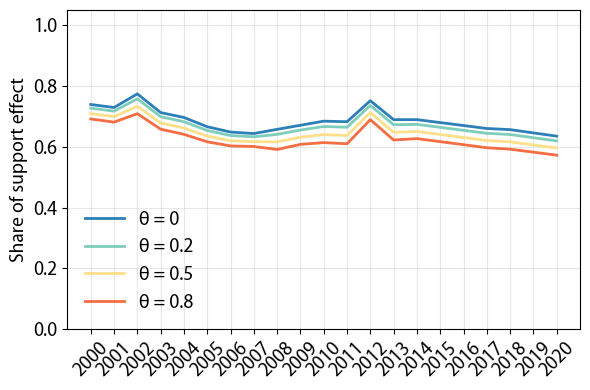

In [32]:
# =========================
# Figure 3:
# Support share under different substitution assumptions
# =========================
fig, ax = plt.subplots(figsize=(6, 4), facecolor='none')
for theta in theta_values:
    g = df_plot[df_plot["theta"] == theta]
    years = g["year"].astype(int)
    ax.plot(
        years,
        g["support_share_theta"],
        linewidth=2,
        label=f"θ = {theta:g}",
        color=colors[theta]
    )
ax.set_ylabel("Share of support effect", fontsize=fss)
# ax.set_title("Stability of supply-chain support share under substitution assumptions")
ax.set_ylim(0, 1.05)
ax.set_xticks(years)
ax.set_xticklabels(years.astype(int), fontsize=fss, rotation=45)
ax.tick_params(labelsize=fss)
ax.legend(fontsize=fss, frameon=False)
ax.grid(alpha=0.3)
ax.set_facecolor('none')
fig.tight_layout()
fig.savefig(out_dir / "support_share_by_theta.png", dpi=300)
plt.show()

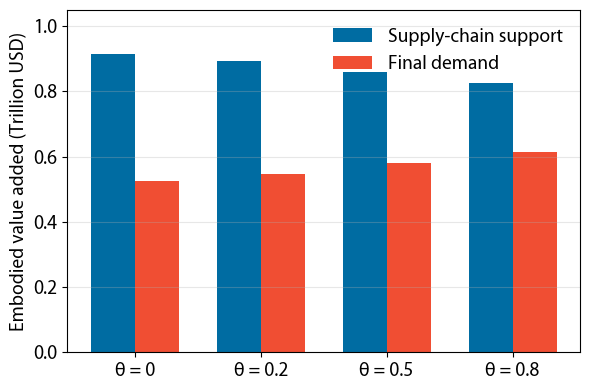

In [38]:
# =========================
# Figure 4:
# Decomposition in 2020 under different substitution assumptions
# =========================
df_2020 = df[df["year"] == 2020].sort_values("theta")
x = np.arange(len(df_2020))
width = 0.35
fig, ax = plt.subplots(figsize=(6, 4), facecolor="none")
ax.bar(
    x - width/2,
    df_2020["DP_Support_theta"]/1e6,
    width,
    label="Supply-chain support",
    color='#006CA2'
)
ax.bar(
    x + width/2,
    df_2020["DP_FinalDemand_theta"]/1e6,
    width,
    label="Final demand",
    color='#F04E33'
)
ax.set_xticks(x)
ax.set_ylim(0, 1.05)
ax.set_xticklabels([f"θ = {v:g}" for v in df_2020["theta"]], fontsize=fss)
ax.set_ylabel("Embodied value added (Trillion USD)", fontsize=fss)
# ax.set_title("Decomposition of DP contribution under alternative substitution assumptions, 2020")
ax.tick_params(labelsize=fss)
ax.legend(fontsize=fss, frameon=False, loc='upper right')
ax.grid(axis="y", alpha=0.3)
ax.set_facecolor('none')
fig.tight_layout()
fig.savefig(out_dir / "2020_decomposition_by_theta.png", dpi=300)
plt.show()

In [24]:
fp = Path("./results/robustness_substitution/robustness_substitution_sector.csv")
df_sector = pd.read_csv(fp)
target_year = 2020
top_n = 10

In [ ]:
# =========================
# Select top sectors based on baseline theta = 0 in 2020
# =========================
df_2020 = df_sector[df_sector["year"] == target_year].copy()
top_sectors = (
    df_2020[df_2020["theta"] == 0.0]
    .sort_values("DP_Support_sector_theta", ascending=False)
    .head(top_n)["sector_name"]
    .tolist()
)
df_top = df_2020[df_2020["sector_name"].isin(top_sectors)].copy()
# Keep sector order based on baseline ranking
df_top["sector_name"] = pd.Categorical(
    df_top["sector_name"],
    categories=top_sectors,
    ordered=True
)
df_top = df_top.sort_values(["sector_name", "theta"])
# Convert to trillion USD
df_top["support_value_scaled"] = df_top["DP_Support_sector_theta"] / 1e6

# =========================
# Pivot for grouped bar chart
# =========================
pivot = df_top.pivot(
    index="sector_name",
    columns="theta",
    values="support_value_scaled"
).loc[top_sectors[::-1]]

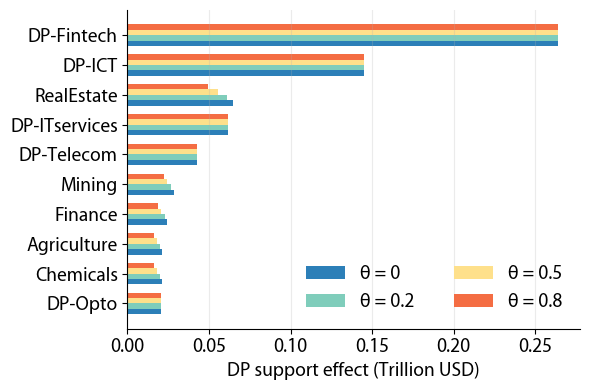

In [35]:
# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(6, 4), facecolor="none")
y = np.arange(len(pivot.index))
bar_h = 0.18
for idx, theta in enumerate(theta_values):
    offset = (idx - (len(theta_values) - 1) / 2) * bar_h
    ax.barh(
        y + offset,
        pivot[theta],
        height=bar_h,
        label=f"θ = {theta:g}",
        color=colors[theta],
        edgecolor="none"
    )
ax.set_yticks(y)
ax.set_yticklabels(pivot.index, fontsize=fss)
ax.set_xlabel("DP support effect (Trillion USD)", fontsize=fss)
ax.tick_params(axis="both", labelsize=fss)
ax.set_ylabel("")
ax.legend(
    frameon=False,
    fontsize=fss,
    ncol=2,
    loc="lower right"
)
ax.grid(axis="x", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_facecolor("none")
fig.tight_layout()
fig.savefig(
    out_dir / "sector_support_robustness_2020.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()